# GAT: learn which neighbors to weight

Three live TODOs feed a complete visible GAT trainer. Default execution performs a five-epoch teaching check and one full seed. Set RUN_100_SEEDS=True to run the full named 100-run Cora experiment; it can take tens of minutes or longer on CPU. Author results are separate from your fresh execution.

In [1]:
# @colab-bootstrap
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch==2.13.0','numpy==2.5.0','scipy==1.18.0','matplotlib==3.11.0'])

<p class="eyebrow">Learned aggregation · one receiver, many senders</p>

## Your win

Implement a GAT attention head, explain which neighbors its softmax compares, and inspect the weights of a trained Cora model. The core lesson takes about 25 minutes; the full experiment is a separate compute session. This brings us closer to the mission: learning how related database rows contribute to predictions, with an auditable experiment behind the claim.

## Retrieve before reading

Write answers first. A wrong prediction gives us something useful to repair.

1. In [GraphSAGE](https://avistian.github.io/relational/lessons/0083-graphsage.html), which operation makes the mean aggregator invariant to neighbor order?
2. In [GCN](https://avistian.github.io/relational/lessons/0082-gcn.html), what determines an edge's propagation weight? Can changing a feature change that weight in the same layer?
3. Does an inductive architecture automatically make every experiment inductive?

<details><summary>Check after answering</summary><p>A sum divided by the neighbor count is symmetric. GCN's normalization depends on graph degrees; features do not change that support matrix. The evaluation protocol determines induction: Cora here exposes the complete graph and all node features during training, while supervising only training labels.</p></details>

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 084</p><p><strong>Build on what you know.</strong> GCN in <a href="https://avistian.github.io/relational/lessons/0082-gcn.html">Lesson 82</a> uses degree-based coefficients; the GraphSAGE mean in <a href="https://avistian.github.io/relational/lessons/0083-graphsage.html">Lesson 83</a> weights sampled neighbors equally. GAT learns coefficients from node states. Compare this with feature-token attention in <a href="https://avistian.github.io/relational/lessons/0046-ft-transformer.html">Lesson 46</a>: the candidate axis is now graph neighbors.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0085-over-smoothing.html">Lesson 85</a> studies repeated mixing. Learned coefficients can change what gets mixed, but the presence of attention alone does not establish immunity to representation collapse or information loss.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>

## Attention is a learned reduction with a local denominator

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">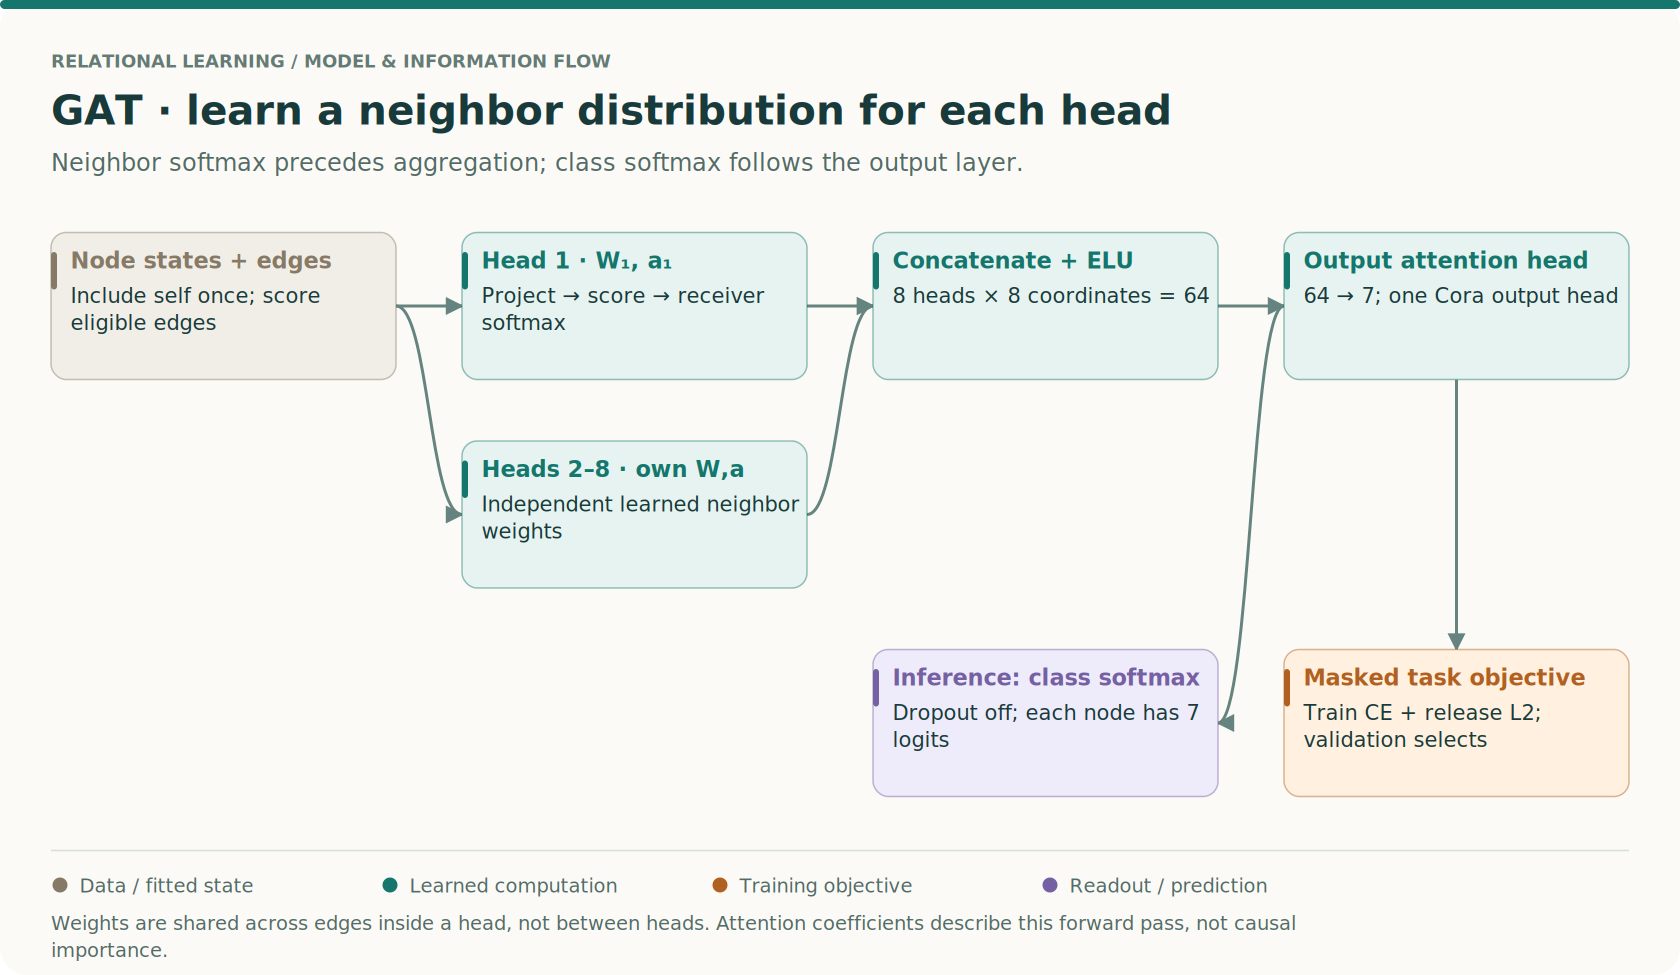</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read one head before the multi-head figure

Read [Veličković et al. §2, Eqs. (1)–(6) and Figure 1](https://arxiv.org/html/1710.10903v3#S2). Mark the order: project → score → neighborhood softmax → weighted sum → combine heads. Unlike dense self-attention over all tokens, the input graph specifies the eligible neighbor pairs.

### Reconstruct a head for one receiver

1. **Project each node once per head.** zᵢ=W hᵢ. A head shares W over nodes, so the same operation can be reused for all eligible edges. A different head has its own parameters.
2. **Score a pair.** Concatenate the receiver and sender projections and apply the learned attention vector, followed by LeakyReLU. The score depends on features; the graph still determines which pairs are allowed to compete.
3. **Normalize per receiver.** Suppose post-activation logits for B's three incoming edges are [0,log(2),0]. Exponentiating gives [1,2,1], so the attention coefficients are [0.25,0.5,0.25]. Do not normalize over every edge in the batch.
4. **Weight the messages.** If the scalar projected sender values are [2,4,8], the output before its activation is 0.25×2+0.5×4+0.25×8=4.5. If an unrelated receiver gains an extra neighbor, B's coefficients must remain unchanged.
5. **Combine hidden heads by concatenation.** Eight heads of width eight make 64 coordinates. Each can select a different weighted view of the neighborhood. Averaging them instead would make an eight-coordinate hidden state and change the next layer.
6. **Produce class logits.** The Cora output configuration has one seven-coordinate head. Class softmax operates over those seven scores, whereas neighborhood softmax operated over edges. Confusing the two axes can produce plausible-looking probabilities for the wrong object.

<details><summary>Check: coefficients sum to one after training-time attention dropout?</summary><p>Not necessarily for an individual dropout realization. Normalized coefficients sum to one before dropout; dropping and rescaling coefficients changes that sample's sum. At evaluation dropout is off. The exact dropout placement is part of the released recipe.</p></details>

**Your intermediate artifact:** write B's logits, denominator, weights and weighted output, then label both softmax axes in the full architecture. Explain why an attention heatmap is a description of a forward pass rather than evidence that an edge causes the outcome.

<!-- depth-walkthrough:end -->

## The question GraphSAGE leaves open

Sampling limits how much context we collect. Mean aggregation then treats every sampled occurrence equally. Suppose one linked document is highly relevant and another is peripheral. Can the aggregator learn different coefficients from their features? GAT makes that choice differentiable. It retains shared parameters and a symmetric weighted sum, so node identifiers and neighbor order are not model parameters. Its Cora experiment uses the whole one-hop neighborhood, including self; it does not inherit L083's sampler. [Primary reading: GAT §2](https://arxiv.org/html/1710.10903v3#S2).

## Trace one receiver before adding heads

Let `i` be the receiver and `j` a sender. An allowed edge is stored as `(receiver, sender)`. Each head projects every node with the same matrix: `z_j = h_j W`. Then it scores an allowed pair:

```text
e_ij = LeakyReLU(a_receiver · z_i + a_sender · z_j, slope=0.2)
alpha_ij = exp(e_ij) / sum_{k in N(i) including i} exp(e_ik)
out_i = sum_j alpha_ij z_j
```

The denominator belongs to **one receiver and one head**. Normalizing across the whole graph couples unrelated neighborhoods. Normalizing across heads makes the heads compete instead of making each head aggregate its neighborhood. The released implementation also has two scalar score biases and an output-vector bias; the lab preserves them. [Released attention head](https://github.com/PetarV-/GAT/blob/5af87e7fce2b90ae1cbd621cd58059036a3c7436/utils/layers.py).

For an arithmetic example, use scalar projected values `[0,1,2]`, receiver contribution zero, sender coefficient one and zero biases. Scores are `[0,1,2]`; softmax is approximately `[0.090,0.245,0.665]`; the weighted value is **1.575**, while the uniform mean is **1.000**. A disconnected node never enters this denominator, however large its feature.

<figure class="mpnn-figure"><small>Scroll horizontally to inspect the diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">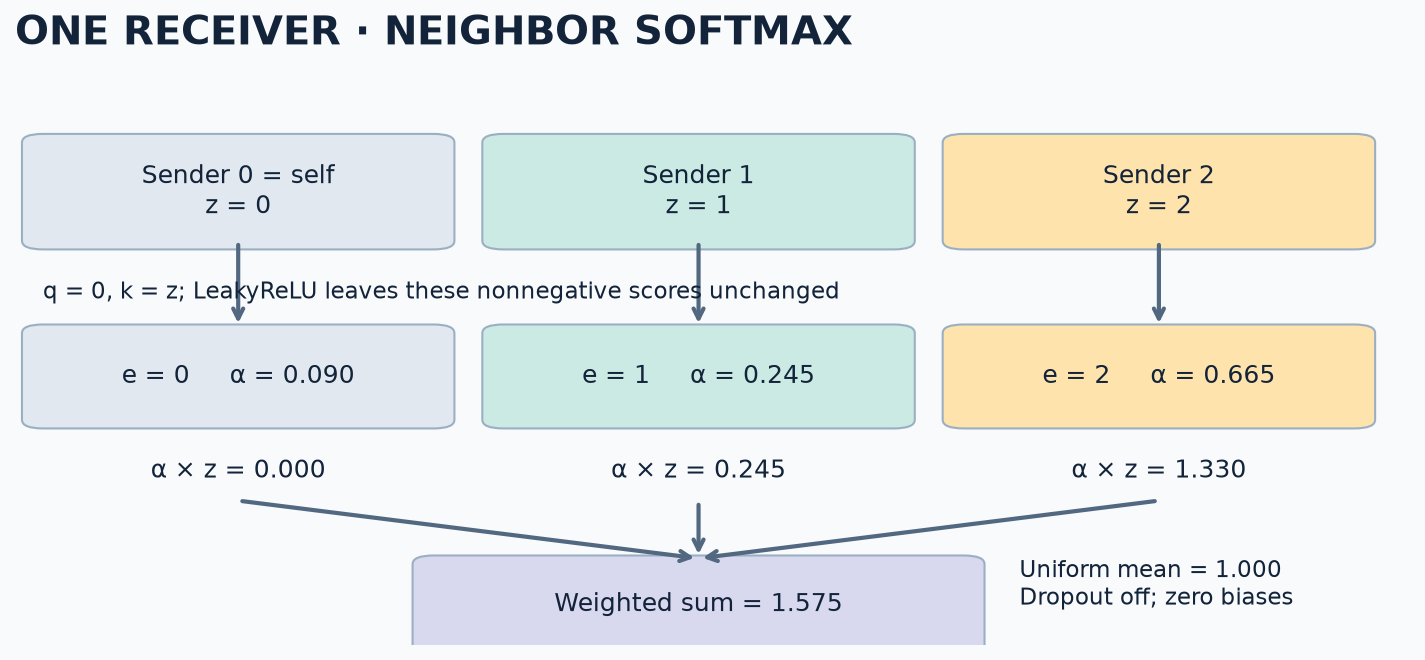</div><figcaption>One receiver, three allowed senders: normalized scores multiply projected values before summation.</figcaption></figure>

**Predict first:** if the third sender disappears, does the second coefficient stay 0.245? Use the control, then explain the denominator change.

**On paper:** recompute after removing sender 2, then change its value to −2 (use the 0.2 negative slope).

<details><summary>Feedback</summary><p>No. The remaining scores [0,1] renormalize to [0.269,0.731], so the output becomes 0.731. Removing one edge changes the remaining weights even if their own scores stay fixed. This is why an attention coefficient is contextual.</p></details>

## Model architecture: eight views, one prediction

<figure class="mpnn-figure"><small>Scroll horizontally to inspect the diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">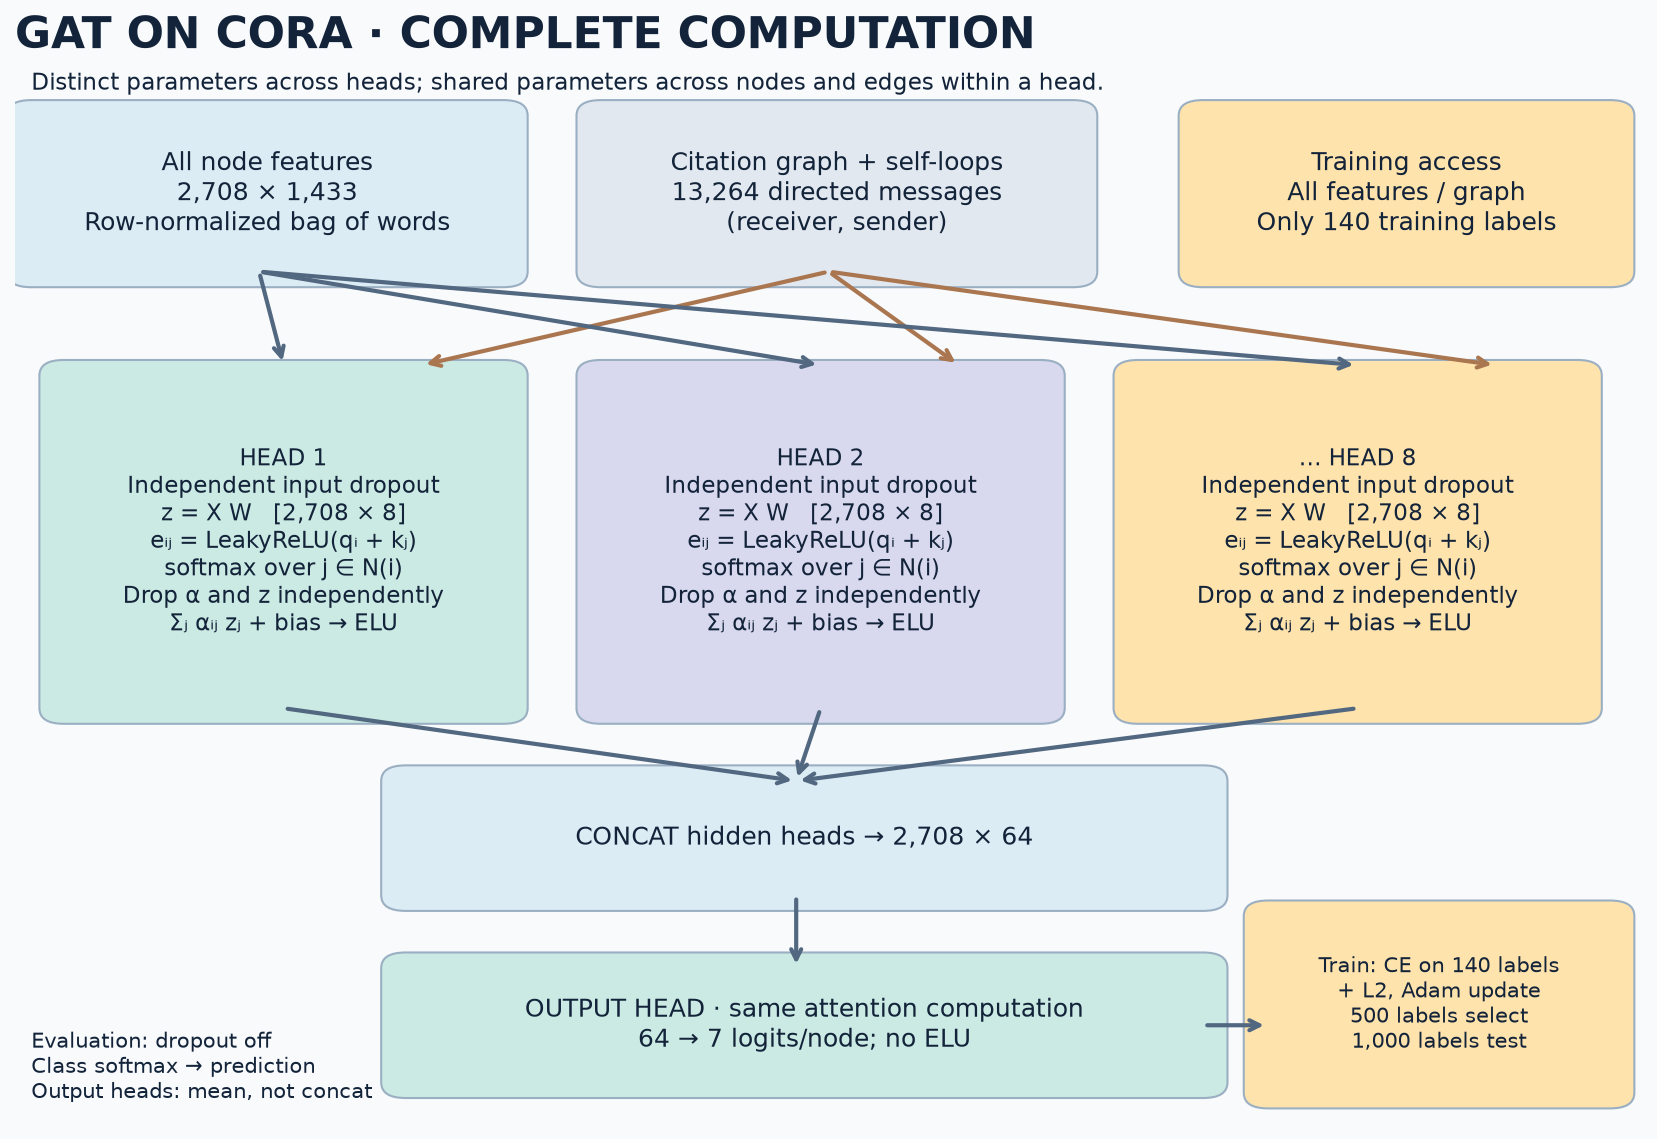</div><figcaption>Full Cora graph and features enter eight independent attention heads, then a class head; masks separate training, selection and testing.</figcaption></figure>

Follow the colored paths: each of eight heads owns a distinct projection and scoring function; those parameters are shared across nodes and edges **within** that head. Each produces eight coordinates. Concatenation preserves all 64 coordinates for the next layer. ELU supplies the hidden nonlinearity. The Cora output uses one seven-coordinate head and seven class logits. With multiple output heads, average matching class logits; concatenation would incorrectly change the number of classes. The final class softmax and the earlier neighbor softmax normalize different axes. [Model construction](https://github.com/PetarV-/GAT/blob/5af87e7fce2b90ae1cbd621cd58059036a3c7436/models/gat.py).

At training time the release drops input features separately per head, computes scores from projected features, then independently drops projected values and normalized coefficients. Coefficient dropout is **after** softmax, with inverted scaling; a realized training row need not sum to one. At evaluation all dropout is off. The graph mask remains fixed in both modes. Do not silently replace these operations with a different library default.

## Implement the three load-bearing operations

The [student notebook](https://avistian.github.io/relational/labs/0084-gat.ipynb) provides the complete loader, head, model, optimizer and checkpoint loop inline. You fill three functions used by that actual trainer:

| TODO | Contract | CHECK catches |
|---|---|---|
| `neighbor_softmax` | Stable normalization by receiver | Global normalization; overflow |
| `weighted_messages` | Sum sender values into receivers | Reversed edges; a second mean |
| `merge_heads` | Hidden concat, output mean | Changed class count |

```python
# Stable segment softmax, with receiver maxima detached as numerical shifts.
maximum = scores.new_full((nodes,), -torch.inf)
maximum.scatter_reduce_(0, receiver, scores.detach(), reduce='amax')
weights = (scores - maximum[receiver]).exp()
denominator = scores.new_zeros(nodes).index_add(0, receiver, weights)
alpha = weights / denominator[receiver]
```

The lab compares this implementation with a dense masked-softmax oracle and checks gradients. Predict a failure, swap receiver and sender, observe the failed check, then restore the code. Passing shape checks alone would not catch a reversed directed message.

## Reproduce a named experiment

Target: **GAT, Table 2, Cora: 83.0 ± 0.7% test accuracy across 100 runs**. This is one fixed split, not 100 independent datasets. Our full port uses all 2,708 nodes, 1,433 row-normalized input features and seven classes; 140 labels train, 500 select, 1,000 test. Both directions of each citation and one self-loop per node form 13,264 directed message entries. [Experiment and reported result](https://arxiv.org/html/1710.10903v3#S3).

The released Adam loop uses learning rate 0.005 and L2 coefficient 0.0005 multiplying half the squared parameter norm. Its name filter includes scoped biases in the penalty. Validation uses cross-entropy without that penalty. Patience resets if **either** validation accuracy or loss improves or ties its best; weights are saved when **both** do so. Restore that saved state before testing. Selecting a maximum test score over seeds would change the experiment. [Trainer](https://github.com/PetarV-/GAT/blob/5af87e7fce2b90ae1cbd621cd58059036a3c7436/execute_cora.py) · [Objective](https://github.com/PetarV-/GAT/blob/5af87e7fce2b90ae1cbd621cd58059036a3c7436/models/base_gattn.py).

**Fresh author execution:** 100 complete runs; mean **83.193%**, sample SD **0.821 percentage points**. The paper reports 83.0 ± 0.7%. All runs use validation-only checkpoint selection. [Every epoch and seed](https://avistian.github.io/relational/labs/_paper_l084_results.json).

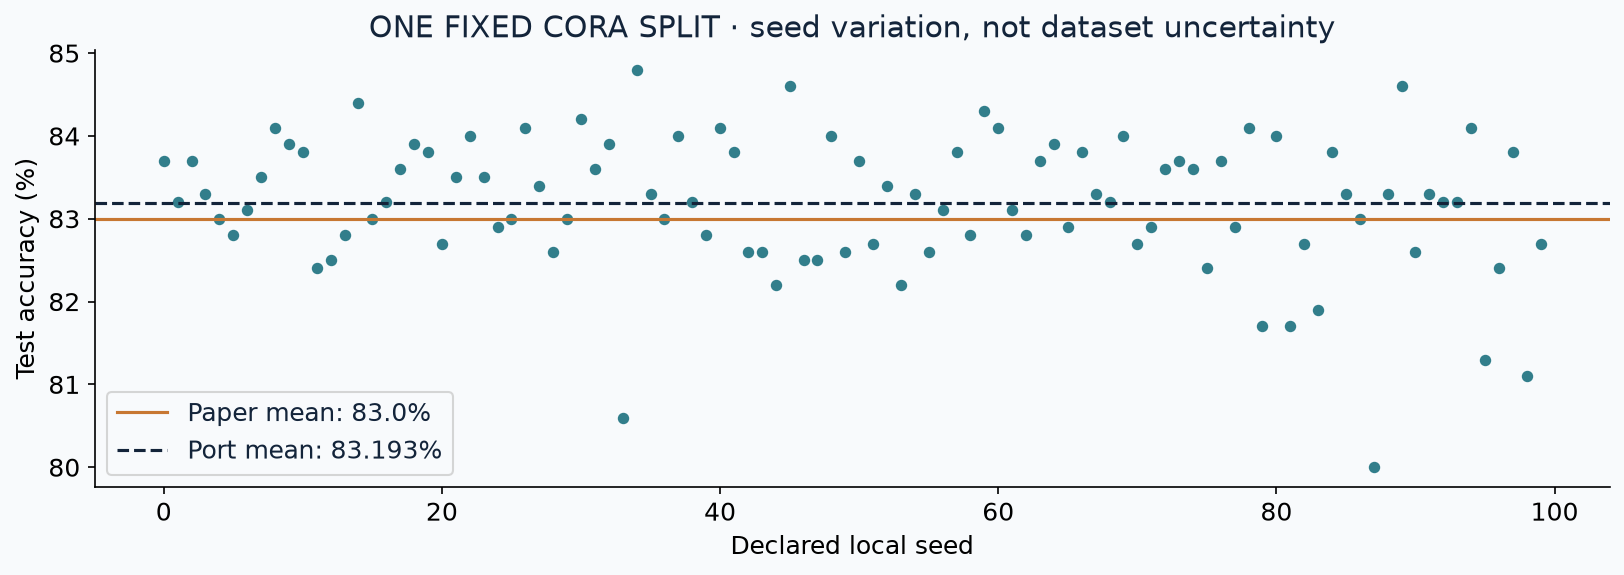

Read the [reproduction contract](https://avistian.github.io/relational/labs/l084-reproduction.md) before comparing numbers. This is a full-data, full-architecture modern port with an explicit deviation ledger: PyTorch rather than TensorFlow 1, edge-only reductions, sparse input dropout and locally declared seeds. Numerical closeness does not establish historical parity. Other datasets and baselines are not included in the Cora experiment.

## Interpret what the model actually learned

<figure class="mpnn-figure"><small>Scroll horizontally to inspect the diagram on narrow screens.</small><div class="figure-scroll" tabindex="0">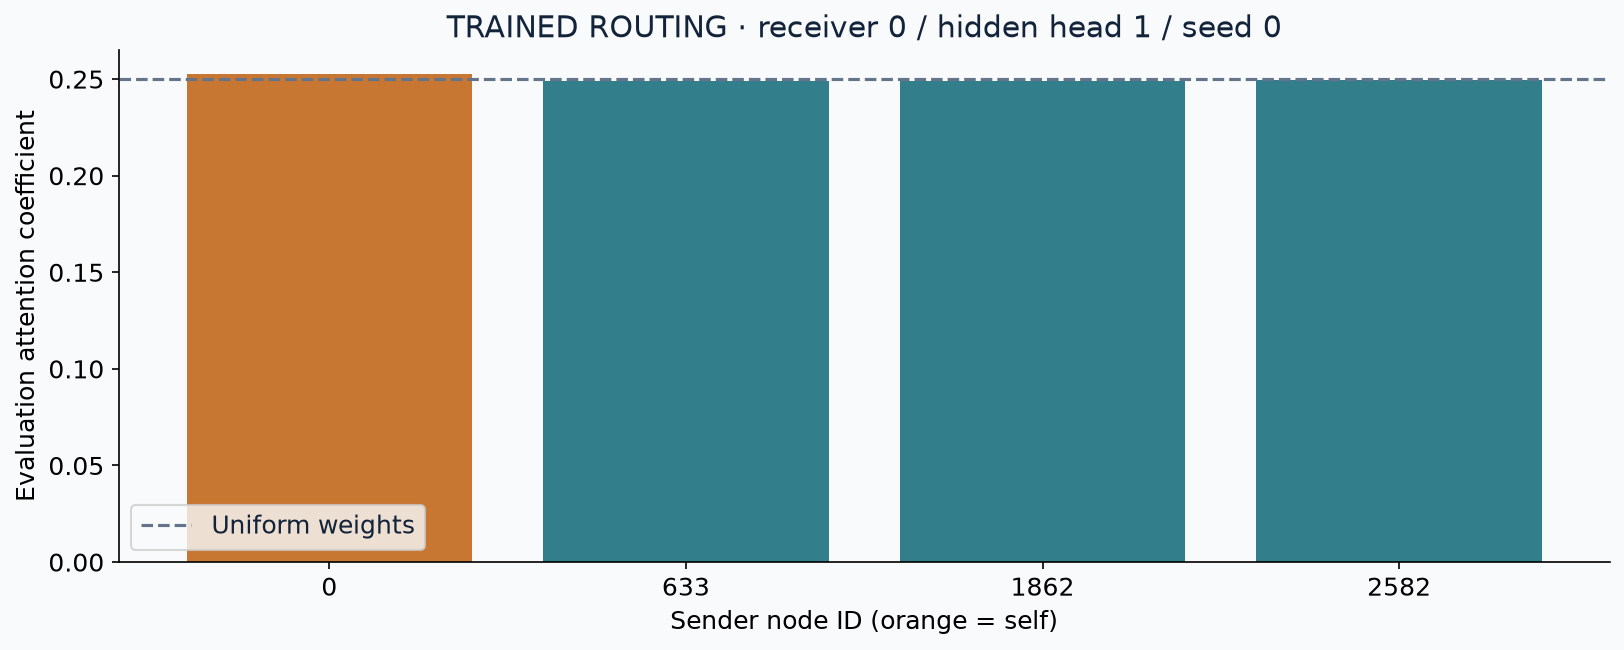</div><figcaption>Actual learned coefficients at receiver 0 from seed 0, hidden head 1; evaluation mode, self included.</figcaption></figure>

This is a selected checkpoint's first head at receiver 0, chosen by node ID before looking at test performance. Each bar belongs to an actual allowed sender; self is included. The weights describe this head's routing with dropout disabled. A large coefficient is not itself a large contribution: multiply it by the transformed value, and remember that other heads and the output layer remain. Removing an edge also renormalizes other coefficients. A causal explanation requires a specified intervention and output comparison.

**Inspect the measurement:** this head's coefficients range from 0.2488 to 0.2525, close to uniform 0.2500. Having learned attention does not guarantee sharply differentiated routing. Compare this trained head with the deliberately stronger arithmetic example above.

**A limitation you can derive:** original GAT scores have the form `LeakyReLU(q_i + k_j)`. For a fixed head and two fixed sender representations, adding the same receiver term and applying a monotone function cannot reverse their ranking. Receiver changes can alter coefficient magnitudes but cannot arbitrarily reorder shared senders. Prove this from the equation; do not assume every architecture called “attention” computes dot-product query–key interactions.

## Exit ticket and next step

Submit your result JSON plus a short explanation. Name the receiver axis, explain hidden concat versus output mean, trace all dropout sites, and distinguish transductive access to features from forbidden test-label training. Include the failed-and-repaired CHECK and explain why the measured attention plot is not a causal feature-importance chart.

For spaced retrieval tomorrow, derive the `[0,1,2]` trace without reopening the lesson. Ask the agent follow-up questions or request a hint on your first failing CHECK. [Contract card](https://avistian.github.io/relational/reference/0084-gat.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/0084-gat.ipynb).

Learned coefficients answer “how much from each neighbor?” They do not remove repeated local mixing or make depth free. Lesson 85 studies over-smoothing: what happens to distinguishability when propagation repeats?


## Attribution and release identity

Port of PetarV-/GAT, pinned 5af87e7fce2b90ae1cbd621cd58059036a3c7436. Original release is preserved in labs/sources/l084. Modern framework differences are in the reproduction contract.

```text
MIT License

Copyright (c) 2018 Petar Veličković

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

```

In [2]:
from pathlib import Path

In [3]:
import copy

In [4]:
import hashlib

In [5]:
import json

In [6]:
import pickle

In [7]:
import time

In [8]:
import urllib.request

In [9]:
import numpy as np

In [10]:
import scipy.sparse as sp

In [11]:
import torch

In [12]:
from torch import nn

In [13]:
import torch.nn.functional as F

### TODO · neighbor_softmax

Normalize edge scores separately for each RECEIVER; stable even for large logits.

In [14]:
def neighbor_softmax(scores, receiver, nodes):
    """Normalize edge scores separately for each RECEIVER; stable even for large logits."""
    maximum=scores.new_full((nodes,),-torch.inf)
    maximum.scatter_reduce_(0,receiver,scores.detach(),reduce='amax',include_self=True)
    weights=(scores-maximum[receiver]).exp()
    denominator=scores.new_zeros(nodes).index_add(0,receiver,weights)
    return weights/denominator[receiver]

In [15]:
r=torch.tensor([0,0,1]);s=torch.tensor([1000.,1001.,-1000.])
a=neighbor_softmax(s,r,2)
torch.testing.assert_close(a,torch.tensor([.26894143,.7310586,1.]))
print('CHECK: stable, separate receiver denominators')

CHECK: stable, separate receiver denominators


### TODO · weighted_messages

edge[0] receives from edge[1]. Sum alpha_ij z_j; never average a second time.

In [16]:
def weighted_messages(z,edge,alpha):
    """edge[0] receives from edge[1]. Sum alpha_ij z_j; never average a second time."""
    return z.new_zeros(z.shape).index_add(0,edge[0],alpha[:,None]*z[edge[1]])

In [17]:
z=torch.tensor([[1.,0.],[0.,2.]])
edge=torch.tensor([[0,0,1],[0,1,1]])
a=torch.tensor([.25,.75,1.])
torch.testing.assert_close(weighted_messages(z,edge,a),torch.tensor([[.25,1.5],[0.,2.]]))
print('CHECK: sender values sum into receivers, no extra mean')

CHECK: sender values sum into receivers, no extra mean


### TODO · merge_heads

Hidden heads concatenate coordinates; prediction heads average class logits.

In [18]:
def merge_heads(heads,concat):
    """Hidden heads concatenate coordinates; prediction heads average class logits."""
    return torch.cat(heads,dim=-1) if concat else torch.stack(heads).mean(0)

In [19]:
a=torch.tensor([[1.,2.]]);b=torch.tensor([[3.,6.]])
torch.testing.assert_close(merge_heads([a,b],True),torch.tensor([[1.,2.,3.,6.]]))
torch.testing.assert_close(merge_heads([a,b],False),torch.tensor([[2.,4.]]))
print('CHECK: concat changes width, averaging preserves classes')

CHECK: concat changes width, averaging preserves classes


### PROVIDED · load_cora

Verify every byte before unpickling pinned Planetoid data; preserve the fixed split.

In [20]:
def load_cora(root,manifest):
    """Verify every byte before unpickling pinned Planetoid data; preserve the fixed split."""
    root=Path(root)
    for record in manifest['data']:
        p=root/record['path'];p.parent.mkdir(parents=True,exist_ok=True)
        if not p.exists():p.write_bytes(urllib.request.urlopen(record['url'],timeout=60).read())
        if hashlib.sha256(p.read_bytes()).hexdigest()!=record['sha256']:raise ValueError('Data hash mismatch: '+str(p))
    folder=root/'data/l078'
    def read(k):
        with (folder/('ind.cora.'+k)).open('rb') as f:return pickle.load(f,encoding='latin1')
    x,y,tx,ty,allx,ally,graph=[read(k) for k in ['x','y','tx','ty','allx','ally','graph']]
    reorder=np.loadtxt(folder/'ind.cora.test.index',dtype=int);ordered=np.sort(reorder)
    features=sp.vstack([allx,tx]).tolil();features[reorder]=features[ordered]
    labels=np.vstack([ally,ty]);labels[reorder]=labels[ordered]
    mass=np.asarray(features.sum(1)).ravel();features=(sp.diags(1/np.maximum(mass,1))@features).tocoo()
    xt=torch.sparse_coo_tensor(np.array([features.row,features.col]),features.data.astype('float32'),features.shape).coalesce()
    edges={(i,i) for i in range(len(labels))}
    for i,neighbors in graph.items():
        for j in neighbors:edges.update([(i,j),(j,i)])
    edge=torch.tensor(sorted(edges)).T.contiguous()
    return xt,edge,torch.tensor(labels.argmax(1)),torch.arange(len(y)),torch.arange(len(y),len(y)+500),torch.tensor(ordered)

### PROVIDED · AttentionHead

Released dense-head semantics: independent input dropout per head; scores use
undropped projected features; independent projected-feature and coefficient dropout.
Two scalar score biases and output bias are included, as in the TF release.

In [21]:
class AttentionHead(nn.Module):
    """Released dense-head semantics: independent input dropout per head; scores use
    undropped projected features; independent projected-feature and coefficient dropout.
    Two scalar score biases and output bias are included, as in the TF release.
    """
    def __init__(self,features,width,dropout=.6):
        super().__init__();self.dropout=dropout
        self.w=nn.Parameter(torch.empty(features,width))
        self.a_receiver=nn.Parameter(torch.empty(width,1));self.a_sender=nn.Parameter(torch.empty(width,1))
        self.b_receiver=nn.Parameter(torch.zeros(()));self.b_sender=nn.Parameter(torch.zeros(()));self.bias=nn.Parameter(torch.zeros(width))
        for p in [self.w,self.a_receiver,self.a_sender]:nn.init.xavier_uniform_(p)

    def forward(self,x,edge,return_attention=False):
        if x.is_sparse:
            values=F.dropout(x.values(),self.dropout,self.training)
            xd=torch.sparse_coo_tensor(x.indices(),values,x.shape).coalesce()
            z=torch.sparse.mm(xd,self.w)
        else:z=F.dropout(x,self.dropout,self.training)@self.w
        q=(z@self.a_receiver).flatten()+self.b_receiver
        k=(z@self.a_sender).flatten()+self.b_sender
        scores=F.leaky_relu(q[edge[0]]+k[edge[1]],negative_slope=.2)
        alpha=neighbor_softmax(scores,edge[0],x.shape[0])
        coefficients=F.dropout(alpha,self.dropout,self.training)
        values=F.dropout(z,self.dropout,self.training)
        output=weighted_messages(values,edge,coefficients)+self.bias
        return (output,alpha) if return_attention else output

### PROVIDED · GAT

Cora: eight independent 8-coordinate heads, ELU, one 7-class output head.

In [22]:
class GAT(nn.Module):
    """Cora: eight independent 8-coordinate heads, ELU, one 7-class output head."""
    def __init__(self,features=1433,classes=7):
        super().__init__();self.hidden=nn.ModuleList([AttentionHead(features,8) for _ in range(8)])
        self.output=nn.ModuleList([AttentionHead(64,classes)])

    def forward(self,x,edge):
        h=merge_heads([F.elu(head(x,edge)) for head in self.hidden],True)
        return merge_heads([head(h,edge) for head in self.output],False)

### PROVIDED · train_cora

Full-batch Adam; released OR-reset / AND-save stopping, including equality.
L2 covers ALL parameters: release compares full variable names against bare names,
so its purported bias exclusion does not exclude scoped bias variables.
Validation uses unregularized CE; test is inspected only after checkpoint restore.

In [23]:
def train_cora(data,seed,max_epochs=100000,patience=100,return_model=False):
    """Full-batch Adam; released OR-reset / AND-save stopping, including equality.
    L2 covers ALL parameters: release compares full variable names against bare names,
    so its purported bias exclusion does not exclude scoped bias variables.
    Validation uses unregularized CE; test is inspected only after checkpoint restore.
    """
    torch.set_num_threads(1);torch.manual_seed(seed)
    x,edge,y,train,valid,test=data;model=GAT(x.shape[1],int(y.max())+1)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005,betas=(.9,.999),eps=1e-8)
    best_loss=float('inf');best_acc=0.;waiting=0;trace=[];selected_epoch=None;state=None
    for epoch in range(max_epochs):
        model.train();optimizer.zero_grad()
        ce=F.cross_entropy(model(x,edge)[train],y[train])
        regularizer=.0005*.5*sum(p.square().sum() for p in model.parameters())
        (ce+regularizer).backward();optimizer.step();model.eval()
        with torch.no_grad():
            logits=model(x,edge);vl=float(F.cross_entropy(logits[valid],y[valid]));va=float((logits[valid].argmax(1)==y[valid]).double().mean())
        trace.append({'epoch':epoch+1,'train_ce':float(ce.detach()),'validation_ce':vl,'validation_accuracy':va})
        improves_acc=va>=best_acc;improves_loss=vl<=best_loss
        if improves_acc or improves_loss:
            if improves_acc and improves_loss:
                state=copy.deepcopy(model.state_dict());selected_epoch=epoch+1
            best_acc=max(va,best_acc);best_loss=min(vl,best_loss);waiting=0
        else:
            waiting+=1
            if waiting==patience:break
    if state is None:raise RuntimeError('No valid checkpoint')
    model.load_state_dict(state);model.eval()
    with torch.no_grad():accuracy=float((model(x,edge)[test].argmax(1)==y[test]).double().mean())
    result={'seed':seed,'epochs':epoch+1,'selected_epoch':selected_epoch,'stopped_by_patience':waiting==patience,'test_accuracy':accuracy,'trace':trace}
    return (result,model) if return_model else result

### PROVIDED · summarize

Seeds measure optimization variation on ONE fixed dataset/split.

In [24]:
def summarize(runs):
    """Seeds measure optimization variation on ONE fixed dataset/split."""
    a=np.array([r['test_accuracy'] for r in runs])
    return {'experiment':'GAT Table 2 Cora; complete release-protocol PyTorch port','paper_mean':.830,'paper_sd':.007,'paper_runs':100,'runs':runs,'mean':float(a.mean()),'sample_sd':float(a.std(ddof=1)) if len(a)>1 else None,'historical_parity':'INCOMPARABLE','deviations':['PyTorch instead of TensorFlow 1; Adam numerical semantics and RNG differ','Edge-only softmax and sparse input dropout instead of dense operations; same deterministic equations, different reduction/random streams','Local seeds 0..99; historical seed identities unavailable'],'not_run':['Original TensorFlow parity','Citeseer, Pubmed, PPI and paper baselines']}

## PROVIDED · data identity and transductive boundary

Pinned files are hashed before deserialization. Features are row-normalized; no fitted statistics cross the split. All features/edges are visible, while only the 140 training labels enter the objective.

In [25]:
manifest={'repository': 'https://github.com/PetarV-/GAT', 'revision': '5af87e7fce2b90ae1cbd621cd58059036a3c7436', 'files': [{'path': 'sources/l084/execute_cora.py', 'upstream': 'execute_cora.py', 'sha256': 'ce4da53957e705554374662cbf3a8e8abc6ebdb0017ddb927622da105623d55a'}, {'path': 'sources/l084/utils/layers.py', 'upstream': 'utils/layers.py', 'sha256': '11aff0e9821e9cf4698870e5702a66e874cd02c864301aafb738bf7d1d0801bb'}, {'path': 'sources/l084/utils/process.py', 'upstream': 'utils/process.py', 'sha256': 'f26aeddd3711c078a6844010cbdf94053dbce0d3342520e3fae817e55d61a7f5'}, {'path': 'sources/l084/models/gat.py', 'upstream': 'models/gat.py', 'sha256': 'bbc44f210b08145415269d5562a783e4bd84f594cc118fb5fd53397df72d4788'}, {'path': 'sources/l084/models/base_gattn.py', 'upstream': 'models/base_gattn.py', 'sha256': '104510d35f4b88294ac9963ccfa808d5a49fd5ce093b46b434771a6f432ae5e7'}, {'path': 'sources/l084/LICENSE', 'upstream': 'LICENSE', 'sha256': '24c1b8432cc4a23404c1da4944776627ae69a41add27adee2d2b4fd18c36662d'}, {'path': 'sources/l084/README.md', 'upstream': 'README.md', 'sha256': '6c9a86a79e351301f3e19dede99099a9b068d54b85b83ea5932002262ff45e6f'}], 'data': [{'path': 'data/l078/ind.cora.ty', 'upstream': 'gcn/data/ind.cora.ty', 'sha256': '41f5ac76596a1699cc33f53084a2419e92961c42bb75f36fc38e616d348532ad', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.ty'}, {'path': 'data/l078/ind.cora.ally', 'upstream': 'gcn/data/ind.cora.ally', 'sha256': '2b998f5cc7fedc86e7f97ca2498f47a1ffc1462c29e2d578b23bf3f62b6e7d71', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.ally'}, {'path': 'data/l078/ind.cora.allx', 'upstream': 'gcn/data/ind.cora.allx', 'sha256': '9419ba2f26f5c35243db64aba110e0f35a04851609e0dc5433450676ca6b8543', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.allx'}, {'path': 'data/l078/ind.cora.test.index', 'upstream': 'gcn/data/ind.cora.test.index', 'sha256': '297ce89af2b51a6a194181c7dbe1796c6a1cf9cd9349a88383b1b1e227867875', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.test.index'}, {'path': 'data/l078/ind.cora.x', 'upstream': 'gcn/data/ind.cora.x', 'sha256': '23cfa55d91c6f624233f5eb7b6e3f141f1bd2b2ae39608a63cf5d084bb27baab', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.x'}, {'path': 'data/l078/ind.cora.y', 'upstream': 'gcn/data/ind.cora.y', 'sha256': '94465c14eb53e04ca262198dcbb2521ee8af60fb3f3d546cd6ca24a511b0e7d1', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.y'}, {'path': 'data/l078/ind.cora.tx', 'upstream': 'gcn/data/ind.cora.tx', 'sha256': 'b9afbaa4a400df991f6f02ef677e1e44da55ffc04801fd02f9e673987829226a', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.tx'}, {'path': 'data/l078/ind.cora.graph', 'upstream': 'gcn/data/ind.cora.graph', 'sha256': '58f13302f39dde8852dad6fe6d15b89b077b6d7f837626bce671ef80344b383d', 'url': 'https://raw.githubusercontent.com/tkipf/gcn/39a4089fe72ad9f055ed6fdb9746abdcfebc4d81/gcn/data/ind.cora.graph'}]}
torch.set_num_threads(1)
data=load_cora(Path.cwd(),manifest)
assert data[0].shape==(2708,1433)
assert data[1].shape==(2,13264)
assert [len(t) for t in data[3:]]==[140,500,1000]
print('Cora verified: all features, fixed label masks')

Cora verified: all features, fixed label masks


/tmp/ipykernel_63799/1405981025.py:10: DeprecationWarning: Please import `csr_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csr` namespace is deprecated and will be removed in SciPy 2.0.0.
  with (folder/('ind.cora.'+k)).open('rb') as f:return pickle.load(f,encoding='latin1')
/tmp/ipykernel_63799/1405981025.py:16: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/Context.cpp:816.)
  xt=torch.sparse_coo_tensor(np.array([features.row,features.col]),features.data.astype('float32'),features.shape).coalesce()


## Teaching lane · deliberately truncated

Five epochs verifies connectivity of your implementation. It is not a benchmark score. Change an edge orientation and watch your CHECK fail before training.

In [26]:
teaching=train_cora(data,999,max_epochs=5)
print('TEACHING ONLY',teaching['test_accuracy'])

TEACHING ONLY 0.381


## One full seed · actual release stopping rule

Full data, width and stopping schedule. A single seed is not the paper's 100-run statistic. The resulting first-head coefficients describe routing; they are not causal importance.

In [27]:
one,model=train_cora(data,0,return_model=True)
print({k:v for k,v in one.items() if k!='trace'})
with torch.no_grad():
    _,alpha=model.hidden[0](data[0],data[1],True)
mask=data[1][0]==0
attention={'receiver':0,'senders':data[1][1,mask].tolist(),'coefficients':alpha[mask].tolist()}
assert abs(sum(attention['coefficients'])-1)<1e-6
print(attention)
Path('l084-inline-seed0.json').write_text(json.dumps(one,indent=2))

{'seed': 0, 'epochs': 659, 'selected_epoch': 557, 'stopped_by_patience': True, 'test_accuracy': 0.837}
{'receiver': 0, 'senders': [0, 633, 1862, 2582], 'coefficients': [0.25253918766975403, 0.24906432628631592, 0.2487753927707672, 0.24962110817432404]}


97692

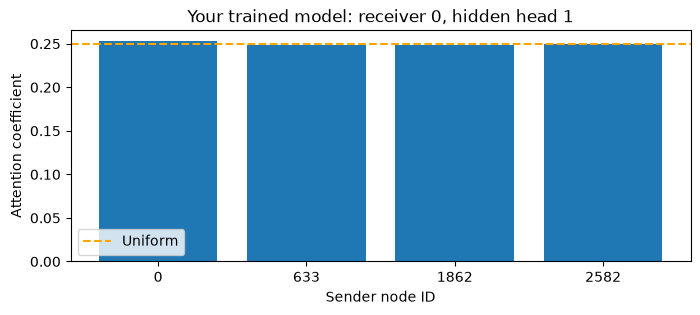

In [28]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,3))
ax.bar([str(v) for v in attention['senders']],attention['coefficients'])
ax.axhline(1/len(attention['senders']),color='orange',linestyle='--',label='Uniform')
ax.set(xlabel='Sender node ID',ylabel='Attention coefficient',title='Your trained model: receiver 0, hidden head 1')
ax.legend()
plt.show()

## Full named experiment · 100 fresh seeds

Set the flag to True to complete the published repetition count. Seed 0 reuses the full fresh run immediately above, not an author checkpoint. No shortened schedule or model. Original-framework parity remains separate. Check environment and source hashes before comparing.

In [29]:
RUN_100_SEEDS = False
if RUN_100_SEEDS:
    runs=[one]
    for seed in range(1,100):
        runs.append(train_cora(data,seed))
        print(seed,runs[-1]['test_accuracy'])
    result=summarize(runs)
    Path('l084-student-results.json').write_text(json.dumps(result,indent=2))
    print(result['mean'],result['sample_sd'])
else:
    print('100-run notebook lane NOT_RUN; one full seed executed above')

100-run notebook lane NOT_RUN; one full seed executed above


## EXIT · attach runnable evidence

Submit your JSON and a written explanation of receiver softmax, concat/mean, transductive feature access, the OR-reset/AND-save rule and why attention is not causal importance. Include a deliberately failing CHECK and its repair. Derive why changing the receiver cannot reverse two shared senders' ranking for a fixed original-GAT head.

In [30]:
artifact={'lesson':84,'source_revision':manifest['revision'],'one_seed_accuracy':one['test_accuracy'],'full_100_seeds':RUN_100_SEEDS,'historical_parity':'INCOMPARABLE','attention':attention,'explanation':'ADD YOUR OWN EXPLANATION'}
Path('l084-exit.json').write_text(json.dumps(artifact,indent=2))
print(artifact)

{'lesson': 84, 'source_revision': '5af87e7fce2b90ae1cbd621cd58059036a3c7436', 'one_seed_accuracy': 0.837, 'full_100_seeds': False, 'historical_parity': 'INCOMPARABLE', 'attention': {'receiver': 0, 'senders': [0, 633, 1862, 2582], 'coefficients': [0.25253918766975403, 0.24906432628631592, 0.2487753927707672, 0.24962110817432404]}, 'explanation': 'ADD YOUR OWN EXPLANATION'}
